# Custom bath correlations and TCL generators

Define a damped-mode bath, compare callable and sampled inputs, and reuse a TCL6 plan to calculate generators and density matrices.

See [setup instructions](README.md) to install FastTCL and open Jupyter. Run the cells in order.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from fasttcl import (
    SampledBath, prepare_model, compile_plan, generator_series, solve,
)


## Define the model and a unit bath

The interaction is $H_I=\lambda A\otimes B$. Keep $\lambda$ out of both $A$ and the reference correlation $C_B$: pass it once as `coupling_strength`.

We use a damped-mode correlation with occupation parameter $\bar n$,

$$C_B(t)=\frac{e^{-\gamma|t|}}{2\bar n+1}
\left[(\bar n+1)e^{-i\omega_0t}+\bar n e^{i\omega_0t}\right].$$

The chosen normalization gives $C_B(0)=1$ and $C_B(-t)=C_B(t)^*$. The function accepts an array of times. Here $\bar n$ controls the relative weights of the two oscillatory components.


In [2]:
mode_frequency = 1.2
decay_rate = 0.4
occupation = 0.25


def unit_correlation(times):
    t = np.asarray(times, dtype=float)
    envelope = np.exp(-decay_rate * np.abs(t))
    oscillations = (
        (occupation + 1.0) * np.exp(-1j * mode_frequency * t)
        + occupation * np.exp(1j * mode_frequency * t)
    )
    return envelope * oscillations / (2.0 * occupation + 1.0)


hamiltonian = np.diag([-0.5, 0.5])
coupling_operator = 0.5 * np.array([[0.0, 1.0], [1.0, 0.0]])
model = prepare_model(hamiltonian, coupling_operator)

lam = 0.25
dt = 0.05
n_steps = 64
times = dt * np.arange(n_steps + 1)

np.testing.assert_allclose(unit_correlation(0.0), 1.0)
np.testing.assert_allclose(unit_correlation(-times), unit_correlation(times).conj())


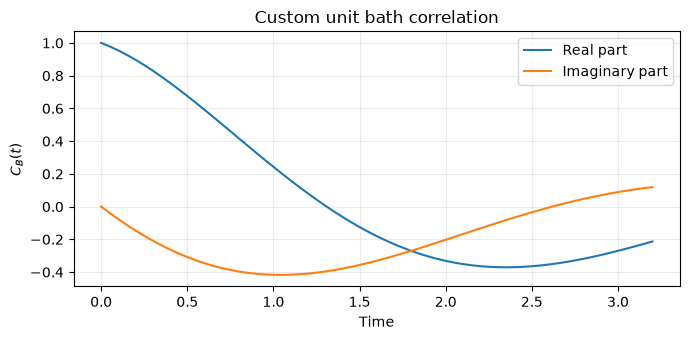

In [3]:
bath_values = unit_correlation(times)
sampled_bath = SampledBath(bath_values, dt)
np.testing.assert_allclose(sampled_bath.correlation(times), bath_values)
np.testing.assert_allclose(sampled_bath.correlation(-times), bath_values.conj())

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(times, bath_values.real, label="Real part")
ax.plot(times, bath_values.imag, label="Imaginary part")
ax.set(xlabel="Time", ylabel=r"$C_B(t)$", title="Custom unit bath correlation")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


## Reuse a plan and inspect each order

`compile_plan(model)` prepares the sixth-order calculation for this $H_S,A$. The same plan can be reused for different baths, time grids, and values of $\lambda$.

`generator_series` evaluates exactly the supplied grid $0,dt,\ldots,Ndt$. Its arrays are in the **energy basis and Schrödinger picture**, with column-major vectorization. Each `corrections[k]` already contains $\lambda^k\mathcal K_{k,S}$. The free Hamiltonian appears separately in `free`; `cumulative(6)` adds it once together with all three corrections.


In [4]:
plan = compile_plan(model)
settings = dict(dt=dt, n_steps=n_steps, order=6, plan=plan)

series = generator_series(model, unit_correlation, coupling_strength=lam, **settings)
from_samples = generator_series(model, sampled_bath, coupling_strength=lam, **settings)
unit_strength = generator_series(model, unit_correlation, coupling_strength=1.0, **settings)

for k in (2, 4, 6):
    np.testing.assert_allclose(
        series.corrections[k], from_samples.corrections[k], rtol=2e-11, atol=2e-13,
    )
    np.testing.assert_allclose(
        series.corrections[k], lam**k * unit_strength.corrections[k],
        rtol=2e-11, atol=2e-13,
    )

expected_total = series.free[None] + sum(series.corrections.values())
np.testing.assert_allclose(series.cumulative(6), expected_total, rtol=2e-13, atol=2e-14)
print("Callable and sampled generators agree; lambda powers are included once.")


Callable and sampled generators agree; lambda powers are included once.


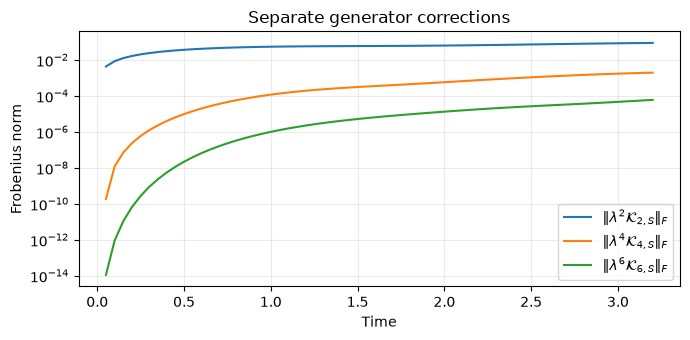

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
for k in (2, 4, 6):
    norms = np.linalg.norm(series.corrections[k], axis=(1, 2))
    # At t=0 all corrections vanish; omit that point on the logarithmic axis.
    ax.semilogy(times[1:], norms[1:], label=rf"$\|\lambda^{k} \mathcal{{K}}_{{{k},S}}\|_F$")
ax.set(xlabel="Time", ylabel="Frobenius norm", title="Separate generator corrections")
ax.legend()
ax.grid(alpha=0.25, which="both")
fig.tight_layout()
plt.show()


## Supply the RK4 half-step grid for propagation

`solve(..., dt=dt, n_steps=N)` returns states every `dt`, but evaluates its generators at `dt/2` so RK4 has actual midpoint samples. A callable is sampled automatically. A `SampledBath` for this solve must contain **$2N+1$ values at spacing $dt/2$**, including zero.

The returned trajectories are in the original laboratory basis. We start in the excited state and compare every cumulative TCL truncation between the two bath representations.


In [6]:
stage_dt = dt / 2.0
stage_times = stage_dt * np.arange(2 * n_steps + 1)
stage_bath = SampledBath(unit_correlation(stage_times), stage_dt)
rho0 = np.array([[0.0, 0.0], [0.0, 1.0]], dtype=complex)
solve_settings = dict(dt=dt, n_steps=n_steps, coupling_strength=lam, order=6, plan=plan)

solution = solve(model, unit_correlation, rho0, **solve_settings)
sampled_solution = solve(model, stage_bath, rho0, **solve_settings)

np.testing.assert_allclose(solution.times, times)
assert len(solution.generators.times) == 2 * n_steps + 1
for k in (2, 4, 6):
    rho = solution.trajectories[k]
    np.testing.assert_allclose(rho, sampled_solution.trajectories[k], rtol=2e-11, atol=2e-13)
    np.testing.assert_allclose(np.trace(rho, axis1=1, axis2=2), 1.0, rtol=0, atol=2e-11)
    np.testing.assert_allclose(rho, rho.conj().transpose(0, 2, 1), rtol=0, atol=2e-11)

max_difference = max(
    np.max(np.abs(solution.trajectories[k] - sampled_solution.trajectories[k]))
    for k in (2, 4, 6)
)
print(f"Callable and sampled dynamics agree: maximum difference {max_difference:.3e}.")


Callable and sampled dynamics agree: maximum difference 0.000e+00.


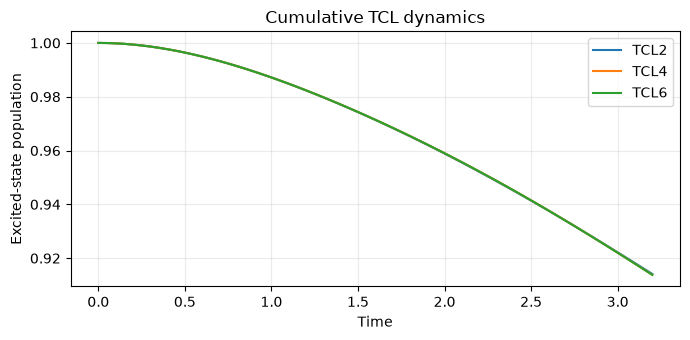

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
for k in (2, 4, 6):
    ax.plot(solution.times, solution.trajectories[k][:, 1, 1].real, label=f"TCL{k}")
ax.set(xlabel="Time", ylabel="Excited-state population", title="Cumulative TCL dynamics")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()
